In [75]:
import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import rlmod as rk
import scipy.linalg as la
import csv
import cmath as cm
import matplotlib as mpl
import matplotlib.pyplot as plt
from numpy import random

mpl.rcParams.update({'font.size': 12})
plt.rcParams['axes.axisbelow'] = True
%matplotlib widget
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.linewidth'] = 2
#mpl.rcParams['axes.prop_cycle'] = cycler(color='bgrkmyc')

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["b", "g", "r", 'k','y' , 'm','tab:orange', 'tab:cyan', 'tab:brown', 'slategrey', 'deeppink' ]) 

In [76]:
bm = 100  # magnitud del pulso
nh = 5  # largo de la cadena
dt = 0.15   # intervalos de tiempo

# secuencias de acciones

action_sequence1 = np.asarray([14, 3, 1, 0, 3, 13, 6, 4, 0, 4, 13, 0, 0, 0, 14, 14, 3, 0,
                               0, 0, 14, 3, 0, 9, 14, 0, 14, 0, 0, 0, 0, 14, 14, 3, 0,
                               0, 0, 14, 3, 14, 14, 14, 9, 6, 14, 0, 6, 14, 14, 14, 14, 0, 5, 14, 14, 14, 5, 14,
                               0, 14, 14, 8, 8, 14, 14, 14, 0, 4, 0, 12, 14, 14, 14, 1, 0, 12,
                               14, 14, 3, 14, 14, 14, 14, 0, 14, 13, 10, 5, 14, 14, 5, 2, 14,
                               9, 9, 0, 14, 3, 1, 14, 9, 0, 5, 8, 5, 14, 0, 0, 14, 14, 0,
                               12, 14, 14, 0, 14, 9, 2, 0, 0, 14, 0, 0, 0, 14, 14, 3, 1, 14, 9,
                               14, 3, 0, 0, 0, 14, 3, 0, 0, 0, 14, 14, 0, 0, 14, 14, 0, 0, 14, 9, 14, 0, 0, 14, 9,
                               14, 0, 0, 5, 0, 0, 5, 3, 5, 0, 5, 8, 5, 9, 4, 0, 0, 5, 8, 5,
                               8, 14, 14, 14, 3, 14, 14, 14, 0, 0, 14, 12, 3, 14, 14, 14, 3,
                               14, 14, 0, 5, 8, 5, 14, 14, 14, 14, 3, 14, 14, 14, 3, 14, 14, 14, 14, 0,
                               0,  14]
                              )

action_sequence2 = np.asarray([14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 0, 0, 14, 14, 14, 14, 0, 13, 0, 0, 8, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 10, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14]
                              )
action_sequence3 = np.asarray([0, 2, 1, 6, 4, 4, 5, 5, 11, 0, 2, 6, 10, 10, 10, 11, 0, 2, 5, 5, 5, 10, 10, 11,
                               15, 0, 2, 6, 10, 11, 15, 0, 2, 5, 11, 0, 2, 6, 9, 10, 9, 9, 11, 15, 0, 2, 6,
                               10, 9, 12, 0, 2, 5, 10, 8, 11, 0, 2, 6, 9, 8, 12, 15, 0, 2, 6, 10, 13, 14, 0, 0,
                               0, 2, 1, 1, 6, 8, 10, 11, 0, 2, 6, 10, 9, 7, 10, 13, 15, 0, 2, 6, 10, 11, 15, 0,
                               2, 6, 11, 15, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 6, 4, 6, 1, 1, 0, 2, 6, 1,
                               0, 2, 7, 8, 8, 1, 0, 2, 6, 5, 3, 4, 6, 1, 8, 1, 1, 0, 2, 6, 1, 1, 1, 1, 0, 0, 0, 2, 1,
                               2, 1, 1, 2, 6, 1, 1, 1, 0, 2, 6, 1, 0, 2, 6, 9, 1, 0, 2, 6, 9, 1, 1, 0, 0, 0, 2, 1, 1, 6, 4,
                               5, 4, 5, 5, 5, 1, 0, 2, 5, 4, 5, 5, 4, 4, 5, 5, 5, 1, 1, 1, 0, 0, 0, 2, 5, 4, 5, 6, 1, 9, 9])

action_sequence4 = np.asarray([6, 5, 3, 3, 3, 3, 3, 3, 3, 3, 3,
                              3, 3, 3, 4, 4, 4, 7, 4, 3, 6, 3, 6, 2, 3, 6, 3, 6, 4, 6, 5, 4])

action_sequence5 = np.asarray(
    [8, 4, 4, 4, 5, 4, 4, 4, 5, 4, 4, 5, 6, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])

action_sequence6 = np.asarray(
    [6, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])



In [77]:
# se generan las matrices de accion 
mat_acc = rk.acciones(bm, nh)
comp_i = complex(0, 1)

# genero matrices para almacenar energías, bases y propagadores
en = np.zeros((16, nh), dtype=np.complex_)
bases = np.zeros((16, nh, nh), dtype=np.complex_)
propagadores = np.zeros((16, nh, nh), dtype=np.complex_)

for j in range(0, 16): # para cada matriz de accion

            en[j, :], bases[j, :, :] = la.eig(mat_acc[j, :, :])

            for k in range(0, nh):
                p = np.outer(bases[j, :, k], bases[j, :,k])

                propagadores[j, :, :] = (
                    propagadores[j, :, :]
                    + cm.exp(-comp_i * dt * en[j, k]) * p
                )
            
            propagadores[j,:,:] = np.matmul(bases[j,:,:],propagadores[j,:,:])
            propagadores[j,:,:] = np.matmul(propagadores[j,:,:],np.transpose(bases[j,:,:]))

c0 = np.zeros(nh, dtype=np.complex_)
e0, base0 = rk.gen_base(nh)
c0[0] = 1.
t = 0


In [78]:
state = c0
fid_evolution = []

ev_real_n = [np.real(state[nh-1])**2]
ev_imag_n = [np.imag(state[nh-1])**2]
ev_real_0 = [np.real(state[0])**2]
ev_imag_0 = [np.imag(state[0])**2]
ev_norm = [la.norm(state)]

action_sequence = action_sequence2
for action in action_sequence:
    
    state = np.matmul(propagadores[action, :, :], state)
    fid = np.real(state[nh-1]*np.conjugate(state[nh-1]))
    #fid = np.real(state[nh-1])**2+np.imag(state[nh-1])**2
    fid_evolution = np.append(fid_evolution,fid)
    
    ev_real_n = np.append(ev_real_n,np.real(state[nh-1])**2)
    ev_imag_n = np.append(ev_imag_n,np.imag(state[nh-1])**2)
    ev_real_0 = np.append(ev_real_0,np.real(state[0])**2)
    ev_imag_0 = np.append(ev_imag_0,np.imag(state[0])**2)
    ev_norm = np.append(ev_norm,la.norm(state))
    

    if abs(la.norm(state) - 1.)>1E8:
        print('FALLO EN LA NORMALIZACION',la.norm(state))

    #else:
        #print('NORMALIZACION OK: ',la.norm(state))


0.6989321750786724
0.6674555382684099
0.8090750842836012
0.5664212337922319
0.6772403238513874
0.5766848679128022
0.646796933715837
0.8373141745194826
0.5879531803071887
0.4943905892072956
0.5875983312800579
0.6465329349410647
0.6981371944684149
0.7429963175131539
0.6494126651227908
0.6590902105532752
0.6017286615464348
0.6656647946089405
0.7900123013007228
0.6539284177156528
0.5893412176869358
0.7440184433833791
0.6964028562693397
0.6624779413042075
0.7369652238752932
0.6428955254323632
0.6579909428483207
0.6528995454774781
0.7263313082128872
0.856447739441498
0.7432652627022285
0.6304324247318397
0.6280607007356499
0.4840845844465692
0.8014436747656091
0.5816778907048279
0.5972630658286087
0.6532554147578317
0.6870296283732813
0.5913936971788625
0.6889587531370639
0.6731034247014619
0.610287688063547
0.6306974995236541
0.7136921202337096
0.5516445275446743
0.7471664927180157
0.7996279839309415
0.5340170949025831
0.7664756483284961
0.6155019720607652
0.6707455953935892
0.7222791382618

Text(0, 0.5, 'Fidelidad')

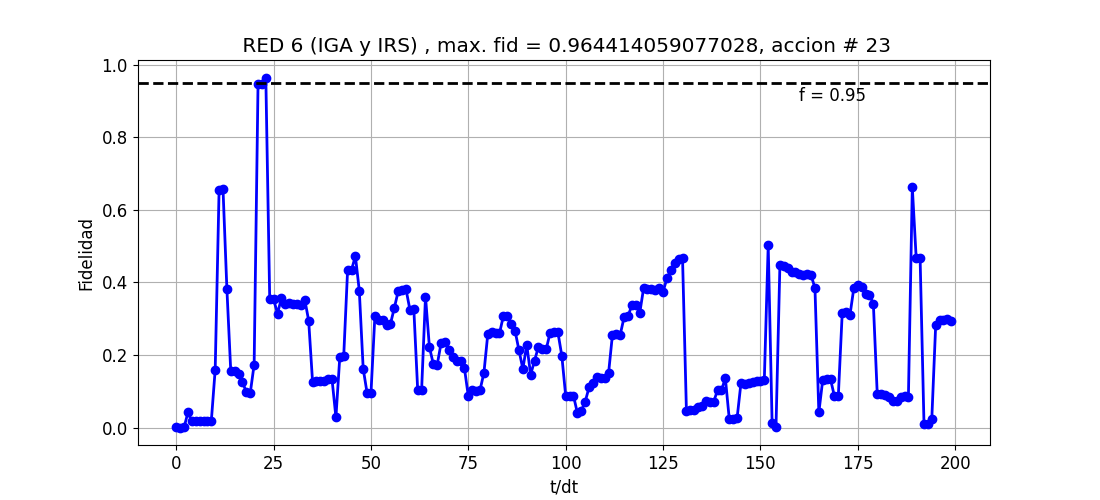

In [79]:
max_fid = 0.
while max_fid < 0.95:    
    state = c0
    fid_evolution = []

    ev_real_n = [np.real(state[nh-1])**2]
    ev_imag_n = [np.imag(state[nh-1])**2]
    ev_real_0 = [np.real(state[0])**2]
    ev_imag_0 = [np.imag(state[0])**2]
    ev_norm = [la.norm(state)]
    action_sequence7 = np.random.randint(0,16,size=200)
    action_sequence = action_sequence7
    for action in action_sequence:
        
        state = np.matmul(propagadores[action, :, :], state)
        fid = np.real(state[nh-1]*np.conjugate(state[nh-1]))
        #fid = np.real(state[nh-1])**2+np.imag(state[nh-1])**2
        fid_evolution = np.append(fid_evolution,fid)
        
        ev_real_n = np.append(ev_real_n,np.real(state[nh-1])**2)
        ev_imag_n = np.append(ev_imag_n,np.imag(state[nh-1])**2)
        ev_real_0 = np.append(ev_real_0,np.real(state[0])**2)
        ev_imag_0 = np.append(ev_imag_0,np.imag(state[0])**2)
        ev_norm = np.append(ev_norm,la.norm(state))
        

        if abs(la.norm(state) - 1.)>1E8:
            print('FALLO EN LA NORMALIZACION',la.norm(state))

        #else:
            #print('NORMALIZACION OK: ',la.norm(state))

    tsteps = np.shape(action_sequence)[0]
    max_fid = np.max(fid_evolution)
    max_action = np.argmax(fid_evolution)
    print(max_fid)
axs = plt.figure(figsize=(11,5))
plt.plot(np.arange(0,tsteps,1),fid_evolution, '-o')
plt.grid()
plt.axhline(y = 0.95, color = 'black', linestyle = '--')
plt.text(tsteps*0.8,0.9,'f = 0.95')
plt.title(' RED 6 (IGA y IRS) , max. fid = {}, accion # {}'.format(max_fid,max_action))
plt.xlabel('t/dt')
plt.ylabel('Fidelidad')

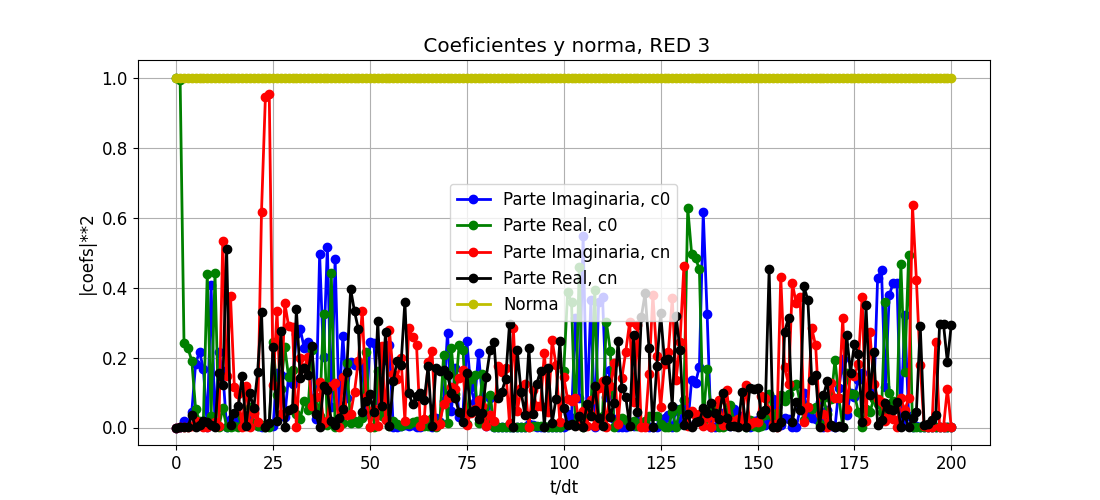

In [80]:
axs = plt.figure(figsize=(11,5))
tsteps = np.shape(action_sequence)[0] + 1
max_fid = np.max(fid_evolution)
max_action = np.argmax(fid_evolution)

plt.plot(np.arange(0,tsteps,1),ev_imag_0, '-o', label = 'Parte Imaginaria, c0')
plt.plot(np.arange(0,tsteps,1),ev_real_0, '-o', label = 'Parte Real, c0')
plt.plot(np.arange(0,tsteps,1),ev_imag_n, '-o', label = 'Parte Imaginaria, cn')
plt.plot(np.arange(0,tsteps,1),ev_real_n, '-o', label = 'Parte Real, cn')
plt.plot(np.arange(0,tsteps,1),ev_norm, '-o', label = 'Norma')
plt.grid()
plt.title(' Coeficientes y norma, RED 3'.format(max_fid,max_action))
plt.xlabel('t/dt')
plt.ylabel('|coefs|**2')
plt.legend()